In [1]:
import os
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.signal import savgol_filter

plt.style.use('bmh')

In [24]:
ruta = "/Users/andresitoortiz/Library/Mobile Documents/com~apple~CloudDocs/Pregrado_Fisica/2025-2/Lab_intermedio/Franck-Hertz/FranckHertz/Actividad_2"
data = {}
for archivo in glob.glob(os.path.join(ruta, "*.csv")):
    nombre = os.path.basename(archivo)
    df = pd.read_csv(archivo, delimiter=';')
    df = df.replace(',', '.', regex=True)
    data[nombre] = df

print("Archivos cargados:", list(data.keys()))
keys=list(data.keys())
print(keys)
print(data.values())

Archivos cargados: ['2_180.csv', '2_185.csv', '2_175.csv', '2_170.csv', '2_165.csv']
['2_180.csv', '2_185.csv', '2_175.csv', '2_170.csv', '2_165.csv']
dict_values([     Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02         0.39
3          0.04          0.4
4          0.07         0.41
...         ...          ...
2454       59.9         5.62
2455      59.92         5.69
2456      59.95         5.73
2457      59.97         5.79
2458      59.99         5.81

[2459 rows x 2 columns],      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02          0.4
3          0.04         0.42
4          0.07         0.44
...         ...          ...
2454       59.9         1.93
2455      59.92         1.95
2456      59.95         1.96
2457      59.97         1.96
2458      59.99         1.98

[2459 rows x 2 columns],      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2

In [51]:
solarized_colors = [
    "#268BD2",  # azul
    "#2AA198",  # verde-azulado
    "#859900",  # verde amarillento
    "#CB4B16",
    "#B58900",  # naranja profundo  # rojo
    "#DC322F",  # amarillo tostado
    "#6C71C4",  # púrpura
    "#586E75"   # gris azulado
]

solarized_figures = [
    's',
    'o',
    '^'
]

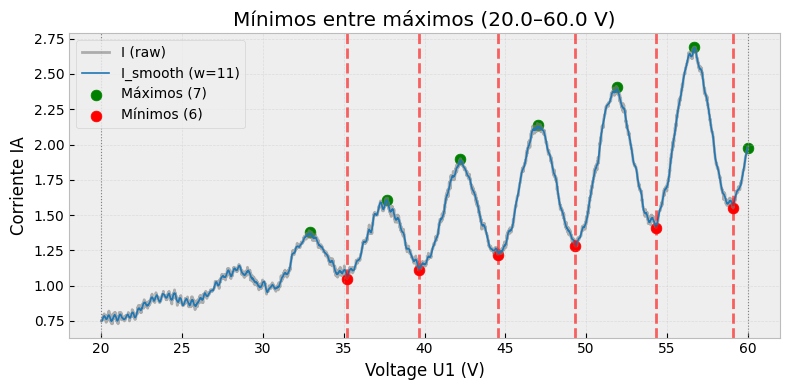

2_185.csv: [35.21 39.63 44.54 49.32 54.33 59.09] mínimos encontrados
2_185.csv: [1.05 1.11 1.22 1.28 1.41 1.55] mínimos encontrados


In [75]:
def minima_between_maximos(V, I,
                           vmin=20.0, vmax=60.0,
                           smooth_window=10, polyorder=3,
                           min_sep_volt=2.0,    # separación esperada entre máximos (V)
                           prominence_max=0.1,  # prominencia mínima para detectar máximos (fracción del rango I)
                           plot=True,
                           title=""):

    # Asegurarse de entradas numpy
    V = np.asarray(V)
    I = np.asarray(I)

    # Filtrar región de interés
    mask = (V >= vmin) & (V <= vmax)
    Vp = V[mask]
    Ip = I[mask]
    

    if len(Vp) < 10:
        raise ValueError("Pocos puntos en la ventana V>={}: len={}".format(vmin, len(Vp)))

    # Suavizado Savitzky-Golay (window impar y menor que N)
    if smooth_window >= len(Ip):
        smooth_window = len(Ip) // 2 * 2 - 1  # máximo impar < N
    if smooth_window % 2 == 0:
        smooth_window += 1

    I_s = savgol_filter(Ip, window_length=smooth_window, polyorder=polyorder)

    # estimar prominencia absoluta a partir del rango de I
    I_range = np.nanmax(I_s) - np.nanmin(I_s)
    if I_range == 0:
        I_range = 1.0
    prom_abs = prominence_max * I_range

    # distancia en puntos entre máximos (convertir voltios -> puntos)
    dV = np.median(np.diff(Vp))
    distance_pts = max(1, int(round(min_sep_volt / dV)))

    # Detectar máximos en I_s
    max_idx, props_max = find_peaks(I_s, distance=distance_pts, prominence=prom_abs)

    # Si no hay suficientes máximos, intentar sin prominence
    if len(max_idx) < 2:
        max_idx, props_max = find_peaks(I_s, distance=distance_pts)

    V_max = Vp[max_idx]
    I_max = Ip[max_idx]  # uso Ip (raw) para marcar; podrías usar I_s[max_idx] si prefieres
    
    if V_max[-1] < Vp[-1] - 0.5:    
        max_idx = np.append(max_idx, len(Vp) - 1)  # <<<<< ESTE ES EL CAMBIO CLAVE
        V_max = np.append(V_max, Vp[-1])
        I_max = np.append(I_max, I_s[-1])

    # Encontrar mínimos entre pares de máximos consecutivos
    V_mins = []
    I_mins = []
    for k in range(len(max_idx) - 1):
        i0 = max_idx[k]
        i1 = max_idx[k+1]
        # buscar mínimo absoluto en I raw dentro de (i0, i1)
        if i1 - i0 <= 1:
            continue
        seg = Ip[i0:i1+1]
        segV = Vp[i0:i1+1]
        rel_idx = int(np.argmin(seg))
        V_mins.append(float(segV[rel_idx]))
        I_mins.append(float(seg[rel_idx]))

    # Plot opcional
    if plot:
        fig, ax = plt.subplots(figsize=(8,4))
        ax.plot(Vp, Ip, color='0.5', alpha=0.6, label='I (raw)')
        ax.plot(Vp, I_s, color='#1f77b4', lw=1.2, label=f'I_smooth (w={smooth_window})')
        ax.scatter(V_max, I_max, color='green', s=60, marker='o', label=f'Máximos ({len(V_max)})')
        ax.scatter(V_mins, I_mins, color='red', s=60, marker='o', label=f'Mínimos ({len(V_mins)})')
        # marcar líneas verticales en los mínimos (si quieres)
        for xv in V_mins:
            ax.axvline(x=xv, color='red', linestyle='--', alpha=0.6)
        ax.axvline(vmin, color='gray', linestyle=':', lw=0.8)
        ax.axvline(vmax, color='gray', linestyle=':', lw=0.8)
        ax.set_xlabel("Voltage U1 (V)")
        ax.set_ylabel("Corriente IA")
        ax.set_title(title or "Mínimos entre máximos ({}–{} V)".format(vmin, vmax))
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return np.array(V_mins), np.array(I_mins), V_max, I_max, I_s

resultados={}

df = data['2_185.csv']
nombre = '2_185.csv'
V = pd.to_numeric(df["Voltage U1"], errors="coerce").to_numpy()
I = pd.to_numeric(df["Corriente IA"], errors="coerce").to_numpy()

Vmin, Imin,_,_,_ = minima_between_maximos(V, I)

resultados[nombre] = (Vmin, Imin)
print(f"{nombre}: {Vmin} mínimos encontrados")
print(f"{nombre}: {Imin} mínimos encontrados")


In [77]:
minimos = {}
for nombre, df in data.items():
    V = pd.to_numeric(df["Voltage U1"], errors="coerce").to_numpy()
    I = pd.to_numeric(df["Corriente IA"], errors="coerce").to_numpy()
    Vmin, Imin,_,_,_ = minima_between_maximos(V, I, plot=False)
    minimos[nombre] = Vmin
    print(f"{nombre}: {Vmin} mínimos encontrados")

2_180.csv: [29.57 34.33 39.14 43.95 48.96 53.79 58.73] mínimos encontrados
2_185.csv: [35.21 39.63 44.54 49.32 54.33 59.09] mínimos encontrados
2_175.csv: [29.79 34.18 39.19 43.95 48.76 53.65 58.6 ] mínimos encontrados
2_170.csv: [29.47 34.33 39.19 43.95 48.86 53.69 58.65] mínimos encontrados
2_165.csv: [29.89 34.23 39.14 44.05 48.91 53.72 58.77] mínimos encontrados


In [38]:
print(resultados['2_165.csv'])

minimos = {}
for key in resultados.keys():
    minimos[key] = resultados[key][0]

print(minimos)

(array([20.51, 25.03, 30.03, 35.04, 44.05, 48.91, 53.72, 58.77]), array([0.84, 1.1 , 1.42, 1.84, 2.26, 2.73, 3.27, 4.05]))
{'2_180.csv': array([20.14, 25.29, 30.06, 35.01, 43.95, 48.96, 53.79, 58.73]), '2_185.csv': array([20.65, 25.81, 30.23, 35.21, 40.02, 45.03, 54.33, 59.09]), '2_175.csv': array([20.31, 25.37, 30.08, 35.01, 43.95, 48.76, 53.65, 58.6 ]), '2_170.csv': array([20.02, 25.  , 30.01, 35.01, 43.95, 48.86, 53.69, 58.65]), '2_165.csv': array([20.51, 25.03, 30.03, 35.04, 44.05, 48.91, 53.72, 58.77])}


In [83]:

def diferencias_minimos(dic_minimos):
    dic_deltas = {}

    for T, Vmins in dic_minimos.items():
        Vmins = np.array(Vmins)
        difs = np.diff(Vmins)   # diferencias consecutivas

        # Crear dict interno: n: diferencia
        dic_deltas[T] = {n+1: difs[n] for n in range(len(difs))}

    return dic_deltas


deltas = diferencias_minimos(minimos)
print(deltas['2_185.csv'])

{1: np.float64(4.420000000000002), 2: np.float64(4.909999999999997), 3: np.float64(4.780000000000001), 4: np.float64(5.009999999999998), 5: np.float64(4.760000000000005)}


T = 165 °C  --->  a = 0.091429 ± 0.058645   |   b = 4.493333 ± 0.228390
T = 170 °C  --->  a = 0.016000 ± 0.016330   |   b = 4.807333 ± 0.063596
T = 175 °C  --->  a = 0.071143 ± 0.052859   |   b = 4.552667 ± 0.205857
T = 180 °C  --->  a = 0.033143 ± 0.022627   |   b = 4.744000 ± 0.088121
T = 185 °C  --->  a = 0.078000 ± 0.070661   |   b = 4.542000 ± 0.234357


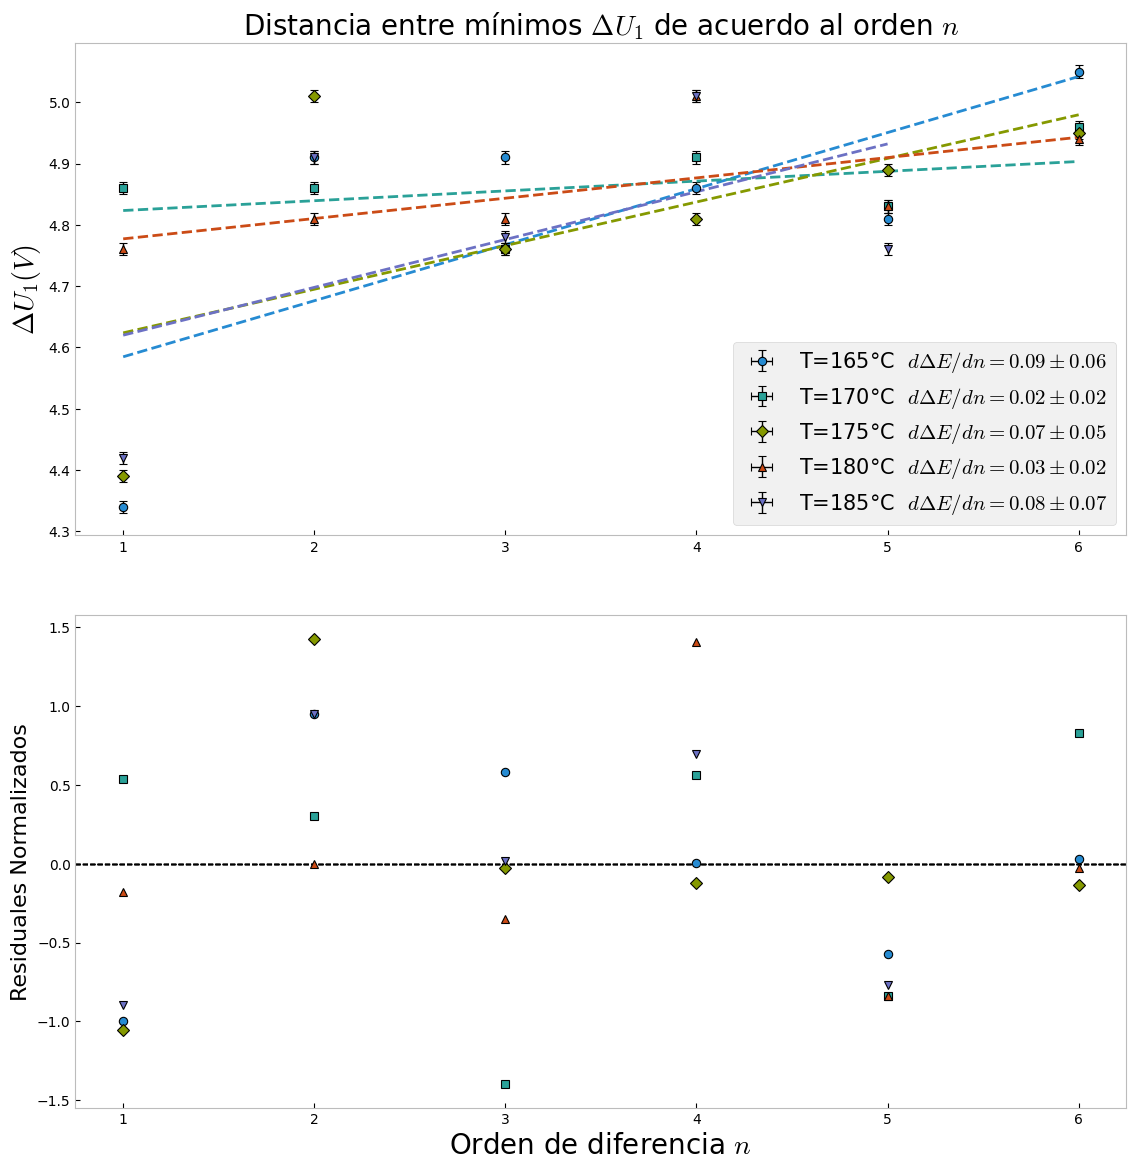

In [109]:
# --- Función lineal ---
def funcion_lineal(x, a, b):
    return a * x + b


# === Diccionario completo de tus ΔU ===
deltas = {
    165: {1: 4.34, 2: 4.91, 3: 4.91, 4: 4.86, 5: 4.81, 6: 5.05},
    170: {1: 4.86, 2: 4.86, 3: 4.76, 4: 4.91, 5: 4.83, 6: 4.96},
    175: {1: 4.39, 2: 5.01, 3: 4.76, 4: 4.81, 5: 4.89, 6: 4.95},
    180: {1: 4.76, 2: 4.81, 3: 4.81, 4: 5.01, 5: 4.83, 6: 4.94},
    185: {1: 4.42, 2: 4.91, 3: 4.78, 4: 5.01, 5: 4.76}
}


# ===== GRÁFICOS =====

fig, axs = plt.subplots(2, 1, figsize=(12, 12))
axs[0].set_facecolor("#FFFFFF")
axs[1].set_facecolor("#FFFFFF")
plt.tight_layout(pad=4)

# Colores y figuras para cada temperatura
temps = sorted(deltas.keys())
solarized_colors = ["#268BD2", "#2AA198", "#859900", "#CB4B16", "#6C71C4"]
solarized_figures = ["o", "s", "D", "^", "v"]

for idx, T in enumerate(temps):

    # Extraer y ordenar por n
    ns = np.array(sorted(deltas[T].keys()), dtype=float)
    ydata = np.array([deltas[T][n] for n in ns], dtype=float)
    xdata = ns.copy()

    # sigma = desviación estándar estimada
    sigma_y = np.std(ydata, ddof=1) * np.ones_like(ydata)

    # Ajuste lineal
    popt, pcov = curve_fit(
        funcion_lineal,
        xdata,
        ydata,
        sigma=sigma_y,
        absolute_sigma=True
    )

    a, b = popt
    a_err, b_err = np.sqrt(np.diag(pcov))

    print(f"T = {T} °C  --->  a = {a:.6f} ± {a_err:.6f}   |   b = {b:.6f} ± {b_err:.6f}")

    # Valores ajustados
    yfit = funcion_lineal(xdata, *popt)

    # Residuales normalizados
    residuales = (ydata - yfit) / sigma_y

    # ======= Gráfico de regresión =======
    axs[0].errorbar(
        xdata, ydata,
        xerr=0, yerr=0.01,
        fmt=solarized_figures[idx],
        color=solarized_colors[idx],
        markersize=6,
        markeredgewidth=0.8,
        markeredgecolor="k",
        capsize=3,
        elinewidth=1,
        ecolor='k',
        label=fr"T={T}°C  $d\Delta E/dn = {a:.2f}\pm{a_err:.1g}$"
    )
    axs[0].plot(xdata, yfit, color=solarized_colors[idx], linestyle="--")

    axs[0].set_title("Distancia entre mínimos " + fr"$\Delta U_1$" +" de acuerdo al orden "+ fr"$n$",fontsize = 20)
    axs[0].set_ylabel(fr"$\Delta U_1 (V)$", fontsize=20)
    axs[0].grid(False)
    axs[0].legend(fontsize=15)

    # ======= Gráfico de residuales normalizados =======
    axs[1].axhline(0, color='k', linestyle = '--',linewidth=1)
    axs[1].errorbar(
        xdata, residuales,
        xerr=0, yerr=0.01,
        fmt=solarized_figures[idx],
        color=solarized_colors[idx],
        markersize=6,
        markeredgewidth=0.8,
        markeredgecolor="k",
        elinewidth=1,
        ecolor='k')
    axs[1].set_xlabel('Orden de diferencia '+fr"$n$", fontsize=20)
    axs[1].set_ylabel("Residuales Normalizados", fontsize=16)
    axs[1].grid(False)

plt.savefig("Regresion_DeltaU_vs_n_TodasTemperaturas.png", dpi=300)
plt.show()

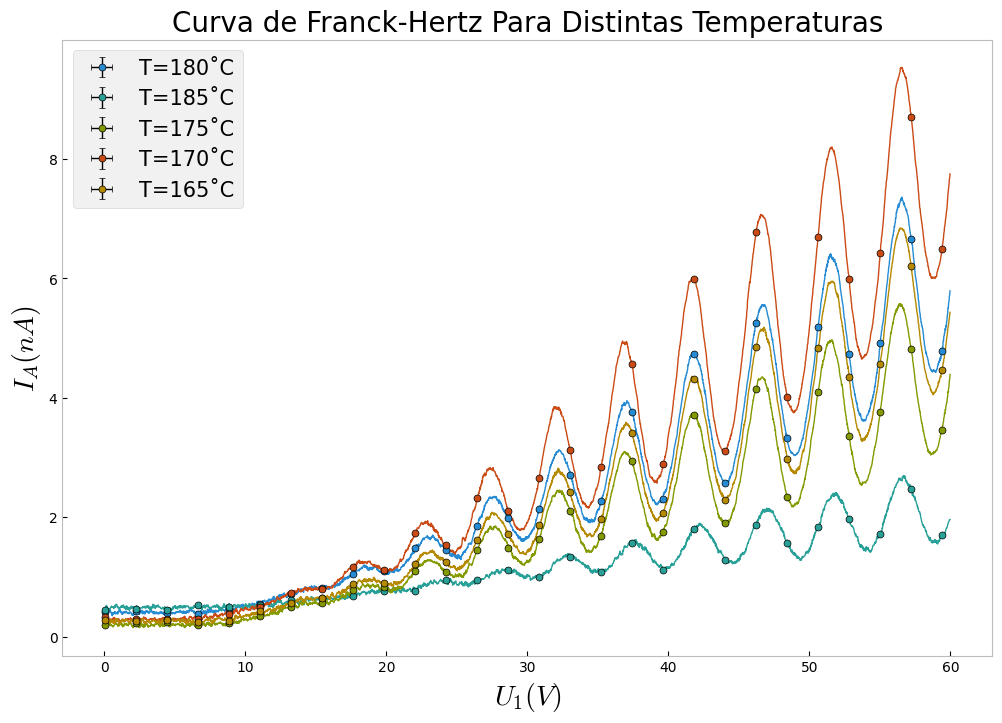

In [16]:
fig,axes = plt.subplots(1,figsize=(12,8))
axes.set_facecolor("#FFFFFF")
i=0

for df in data.values():
    dff = df[2:-1].astype(float)
    x = dff["Voltage U1"]
    y = dff["Corriente IA"]
    
    axes.errorbar(x[2:-1:90], y[2:-1:90],
        xerr=0.01, yerr=0.01,
        fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
        capsize = 2, elinewidth = 1, ecolor = 'k',
        label=f'T={keys[i][2:5]}˚C')
    axes.plot(x, y, color = solarized_colors[i], linewidth = 1)
    
    i+=1
axes.set_title("Curva de Franck-Hertz Para Distintas Temperaturas", fontsize=20)
axes.set_xlabel(fr"$U_1 (V)$", fontsize=20)
axes.set_ylabel(fr"$I_A (nA)$", fontsize=20)
plt.legend(fontsize=15)
plt.grid(False)    
plt.savefig("Curvas_Franck_Hertz_Temperaturas.png", dpi=300)
plt.show()